<span style="font-size:18px">**Download this Notebook**</span>

Click <a href="https://github.com/serc-chile/SERCpy/releases/download/demand_profile_tutorial/DemandProfile_tutorial.ipynb" download>here</a> to download this file and run it locally in your machine.

<br>

# DemandProfile class tutorial

`DemandProfile` instances compute, store, and provide the thermal demand  of a heating system during a whole operation year.  

They allow the user to introduce daily demand profiles with time resolutions as small as 30 minutes.  

They also take into account the dependence of the demanded power on the ambient temperature, also being capable of determining that degree of dependence based on the monthly heat demand provided by the user.

In [1]:
# Import DemandProfile and other modules needed
# If the two last code lines are activated, the plots will be rendered in separate windows

from sercpy.demand_profile import DemandProfile
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'qt')

## 1. Introducing the monthly heat demand

The most essential data needed to construct a high-resolution yearly demand profile is the total amount of energy demanded by the thermal load.

This demand must be specified as a list of 12 values, each one representing the energy demanded during one month of the year (from Juanuary to December). The name of this parameter is `monthly_heat_demand`.

The user must also specify the energy units in which the monthly demand is being specified. The name of this parameter is `heat_demand_units`. Accepted values are: `"kWh"`, `"MWh"`, `"BTU"`, `"kBTU"`, `"MBTU"`, `"J"`, `"kJ"`, `"MJ"`, `"TJ"`.

A very simple (and most certainly unrealistic) example is the following, in which the user demands 1 MWh of thermal energy each month.

In [2]:
# Establishing a simple monthly heat demand
monthly_heat_demand = [ 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1 ]
heat_demand_units = "MWh"

Other essential parameters to construct the profile are `T_in`, `T_set`, and `fluid`.

`T_in` represents the temperature with which the heat transfer fluid enters the heating system (in other words, the temperature with which it returns from the thermal load), in °C. `T_set` represents the temperature to which the heating system must heat the flow, in °C. Both of these parameters can either be a single numeric value, or a list of 12 values. In the latter case, each value represents the inlet temperature or the setpoint for one month of the year, from January to December.

`fluid` is a string to designate the heat transfer fluid. Possible values are `"water"`, `"air"`, and `"therminol 66"`.

In [3]:
# Setting 'T_in', 'T_set', and 'fluid'
T_in = 40
T_set = 60
fluid = 'water'

In [4]:
# The variables defined up to this point are enough to generate a DemandProfile instance
demand_1 = DemandProfile(
    T_in = T_in,
    T_set = T_set,
    fluid = fluid,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units )

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


The `DemandProfile` instance just defined throws a warning pointing out that dependence of thermal demand on ambient temperature could not be computed. This will be addressed in Section 5 of this tutorial.

### 1.1. What if I have fuel consumption data instead of heat demand?

For many users, it may be much easier to access data about fuel (or electricity) consumption rather than the hardly-ever-measured thermal energy demanded by the load.

The thermal demand is easy to extract from this data, assuming that the efficiency of the heater can be estimated to be constant. For this construction mode to work, the user does not have to provide the parameters `monthly_heat_demand` and `heat_demand_units`, but the following:

- `heat_source`: string designating the name of the heat source. Accepted values:
    - `"electricity"`
    - `"liquefied petroleum gas"` or `"lpg"`
    - `"natural gas"` or `"ng"`
    - `"methane"` or `"CH4"`
    - `"propane"` or `"C3H8"`
    - `"butane"` or `"C4H10"`
    - `"diesel"`
    - `"coal"`
    - `"biomass"`
- `monthly_consumption`: list of 12 values, similar to `monthly_heat_demand`, but representing the quantity of heat source consumed each month of the year.
- `consumption_units`: string designating the units of the values in the list `monthly_consumption`. For heat sources other than electricity, the accepted values are: `"kg"`, `"ton"`, `"lb"`, `"m3"`, `"L"`, `"gal"`, `"ft3"`. For electricity, the accepted values are the same as the energy units accepted for the parameter `heat_demand_units`.
- `heater_efficiency`: Heater efficiency as a decimal floating point number (e.g. 80% efficiency must be specified as 0.8). If not provided, the value is automatically set to 0.8.

The user can customize the density and the heating value of the fuel used by the heater by setting the optional parameters `heat_source_density` and `heat_source_heating_value`. The density must be expressed in kg/m3, and the heating value must be expressed in J/kg. If both of these parameters are specified, then the parameter `heat_source` becomes unnecessary.

By default, the platform considers the lower heating value of the fuel to compute the heat demand. To consider the higher heating value, the user can set the optional parameter `condensation_boiler` to the boolean value `True`.

In [5]:
# Establish the heat demand by providing the monthly consumption of the heat source.
# In this case, the heat source corresponds to liquefied petroleum gas.

heat_source = "liquefied petroleum gas"
monthly_consumption = [ 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500 ]
consumption_units = "m3"
heater_efficiency = 0.78

# Construct a DemandProfile instance from the monthly consumption just specified
demand_1 = DemandProfile(
    T_in = T_in,
    T_set = T_set,
    fluid = fluid,
    heat_source = heat_source,
    monthly_consumption = monthly_consumption,
    consumption_units = consumption_units,
    heater_efficiency = heater_efficiency )

## 2. Introducing profiles

Up to this point, no information has been provided on the daily operation schedule of the thermal load. Therefore, the `DemandProfile` instance assumes that the thermal load operates 24 hours a day with constant demanded power. This assumption is quite unrealistic for most cases.

### 2.1. Daily demand profiles

The most precise way of providing information on how energy demand is distributed throughout the day is by introducing a daily demand profile, which consists of a `list` of up to 48 values. These 48 values represent a 24-hour day with 30-minute resolution. This `list` can also have less values. In this case, the number of values must be a divisor of 24, or 24 itself. For example, an 8-value `list` defines a daily demand profile with each value encompassing 3 hours of the day.

To make this process easier, the class includes a small app to define the profiles in a more graphical way.

In [6]:
# Open app to define profiles. The lists are printed in a text box and must be copied and pasted to the code.
DemandProfile.open_profiles_app()

<div style="text-align: center;">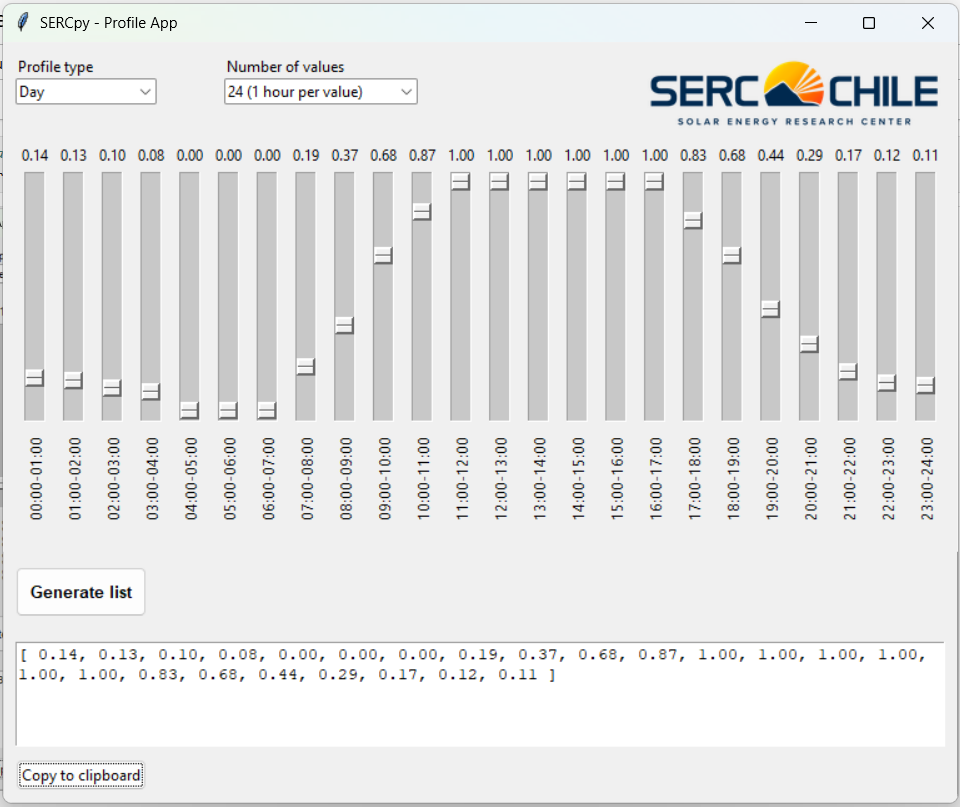</div>
<div style="text-align: center; font-weight: bold;">Profile App at the moment of generating the daily demand profile</div>

<br>

The daily demand profile shown in the screenshot above has been copied and pasted in the next code cell to define the daily demand profile.

**Something very important to understand about daily demand profiles is that the values do not have any energy or power units. All they define is how demand gets *distributed* throughout the day; hence, the total amount of energy, which is known beforehand, gets assigned proportionally to the values of the profile. Thus, what matters is the values relative to each other.**

In [7]:
# The following profile has been copied and pasted from the app
daily_demand_profile = [
    0.14, 0.13, 0.10, 0.08,
    0.00, 0.00, 0.00, 0.19,
    0.37, 0.68, 0.87, 1.00,
    1.00, 1.00, 1.00, 1.00,
    1.00, 0.83, 0.68, 0.44,
    0.29, 0.17, 0.12, 0.11 ]

In [8]:
# Now it is possible to initialize a new DemandProfile instance with this daily profile and the other parameters already defined

demand_1 = DemandProfile(
    
    daily_demand_profile = daily_demand_profile,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

### 2.2. Plotting the weekly profile of a DemandProfile instance 

The attribute called `"weekly_demand_profile"` is a `list` of 336 values that defines how heat demand gets distributed during an entire week. The number of values of the list comes from the fact that this profile has a 30-minute resolution, no matter the time-resolution with which the user introduced the daily demand profile.

Notice that this profile is only a baseline to construct the yearly profile. In the actual yearly profile, the demand will vary from day to day because of other factors such as the ambient temperature; this will be discussed in Section 5 of this tutorial.

In the next cell, a function to plot the weekly demand profile of a DemandProfile instance will be defined and used. It will also be used in the following examples to appreciate the effect of other DemandProfile construction methods. Since in this case a single daily profile was provided, all days are equal.

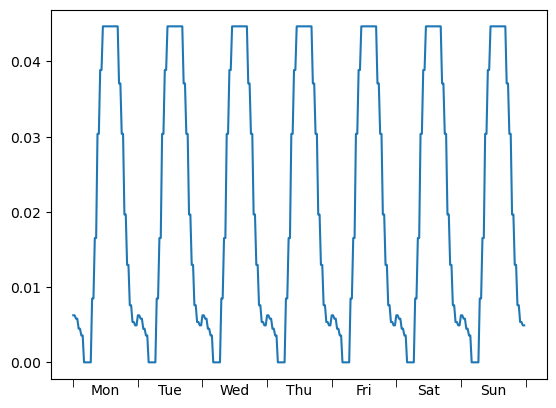

In [9]:
# Function to plot the weekly demand profile of a DemandProfile instance.
def plot_weekly_profile( demand_profile_instance ):
    # Get the attribute 'weekly_profile' from the object
    weekly_profile = demand_profile_instance.get_attribute( "weekly_demand_profile" )
    
    # Plot the profile
    fig, ax = plt.subplots()
    plt.plot( weekly_profile )
    
    # Show week day names in the horizontal axis
    day_names = [ 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun' ]
    n_days = 7
    len_day = len( weekly_profile )//n_days
    edges = len_day * np.arange(n_days + 1) # Where to draw lines
    centers = len_day * (np.arange(n_days) + 0.5) # Where to write day names
    
    # Major ticks: labels only, no visible tick marks
    ax.set_xticks(centers)
    ax.set_xticklabels(day_names)
    ax.tick_params(axis='x', which='major', length=0)
    
    # Minor ticks: the dividing lines at section boundaries, no labels
    ax.set_xticks(edges, minor=True)
    ax.tick_params(axis='x', which='minor', length=6)
    
    plt.show()

# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### 2.3. Daily operation schedule from operation start and operation end time

An even simpler way of producing daily (and from them weekly) demand profiles is to specify the time of the day when the system operation starts and when it ends. This is done with the parameters `op_start` and `op_end`.

These parameters must be strings representing a time of the day in the format `"hh:mm"`. The "minutes" component of the time (i.e. the string `"mm"`) must be either `"00"` or `"30"`, since the maximum resolution for these profiles is 30 minutes. The "hours" component must have values from `"00"` to `"24"`. When midnight is the start of the operation time, it should be represented as `"00:00"`. When it is the end time, it should be represented as `"24:00"`.

When the daily profile is specified in this way, the rate of energy demand is assumed to be flat during the operation time of the thermal load.

In [10]:
# Defining the times at which operation starts and ends
op_start, op_end = "08:00", "18:00"

# Constructing the DemandProfile instance
demand_1 = DemandProfile(

    op_start = op_start,
    op_end = op_end,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


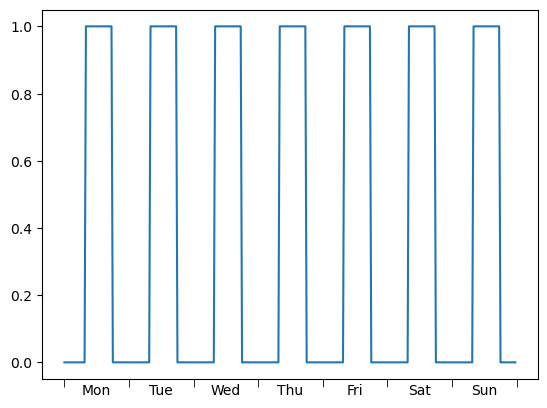

In [11]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### 2.4. Using the Profile App to specify the monthly demand

In Section 1 of this tutorial, a very simple monthly heat demand was specified. The App to generate profiles can also be used to generate monthly demand and monthly consumption profiles. To do that, the "Profile type" must be switched from "Day" to "Year".

In contrast with the case of daily demands, the heat demand and the consumption ***do*** have units. Therefore, a "Total" value (representing the yearly total heat demand or consumption) must be introduced. At the moment of generating the list, this value will be distributed proportionally to the "heights" of the sliders.

<br>

<div style="text-align: center;">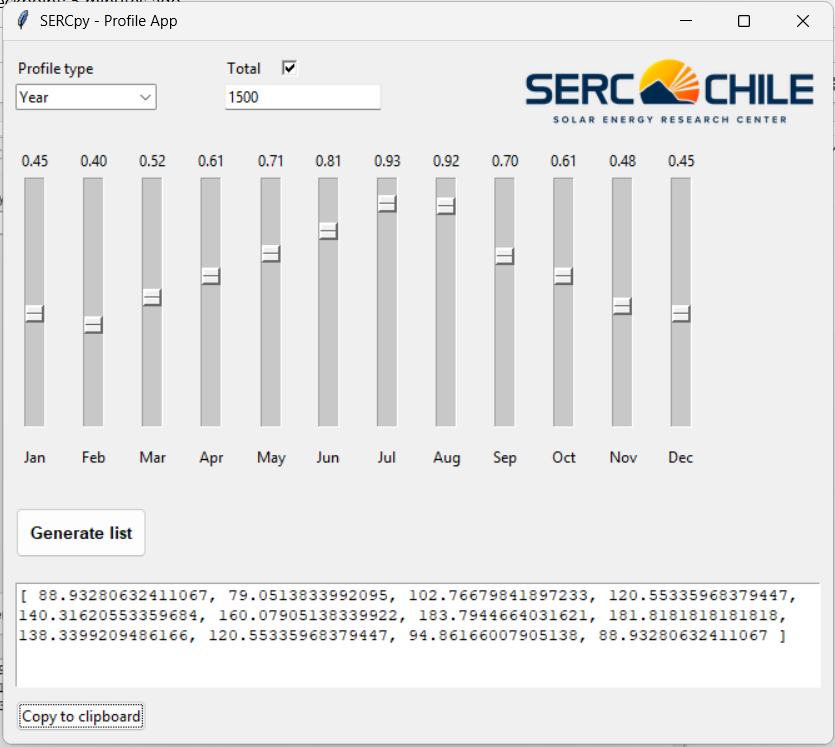</div>
<div style="text-align: center; font-weight: bold;">Profile App at the moment of generating the monthly heat demand</div>

In [12]:
# Open the Profile App again to specify the monthly heat demand
DemandProfile.open_profiles_app()

In [13]:
# Define the list of monthly heat demands, along with the heat demand units
monthly_heat_demand = [
    88.93280632411067, 79.0513833992095, 102.76679841897233,
    120.55335968379447, 140.31620553359684, 160.07905138339922,
    183.7944664031621, 181.8181818181818, 138.3399209486166,
    120.55335968379447, 94.86166007905138, 88.93280632411067 ]
heat_demand_units = "MWh"

## 3. Establishing weekend days as special days

Many users, especially in the industrial sector, may find it important to specify special demand conditions for saturday and sunday, while leaving the other five days of the week as "regular" or "normal" days.

For all the parameters discussed in this section, there is an important rule that applies:

- **If a special condition is specified for sunday but not for saturday, saturday is assumed to be a "normal" day.**
- **If a special condition is specified for saturday but not for sunday, sunday is assumed to have no demand at all.**

### 3.1. Daily demand ratios

One way to declare special demand conditions for saturday and sunday is by introducing the parameters `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday`.

This parameters are defined as the ratio between the total daily demand for the respective day and a "normal" week day. For instance, by setting the parameter `daily_demand_ratio_saturday` to 0.4, the user is establishing that the total daily demand on saturdays is 40% of the demand on week days. **If only this parameter is set, sunday will have zero demand.**

This technique can be combined both with the "daily profile" approach and with the "operation start and operation end time" approach.

In [14]:
# Setting a different demand only for saturday
# Sunday is thus assumed to have no demand

daily_demand_ratio_saturday = 0.6

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


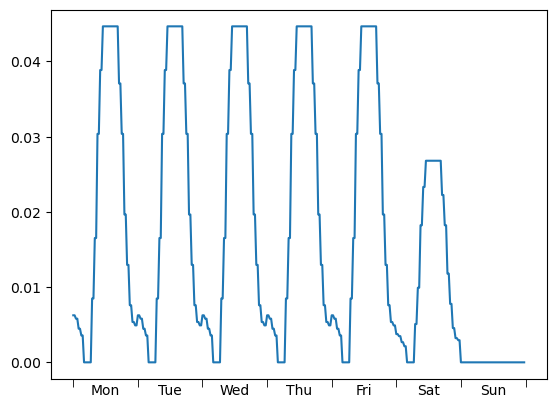

In [15]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

In [16]:
# Setting a different demand only for sunday
# Saturday is thus assumed to be a normal day

daily_demand_ratio_sunday = 0.3

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_ratio_sunday = daily_demand_ratio_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


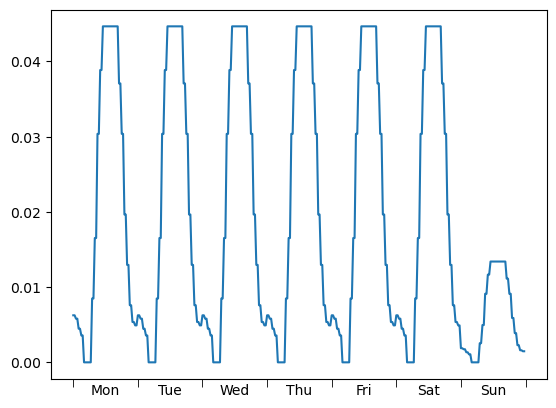

In [17]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

In [18]:
# Setting different values for both weekend days

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    daily_demand_ratio_sunday = daily_demand_ratio_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


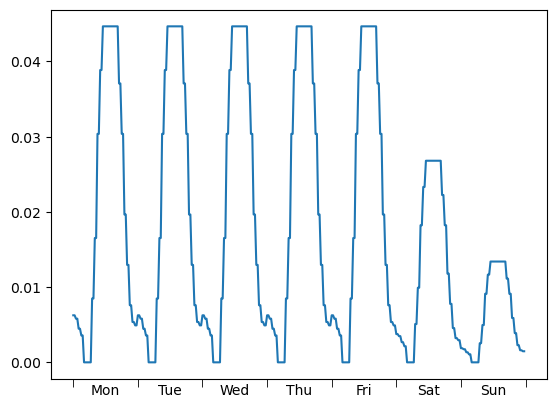

In [19]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### 3.2. Special demand schedules for weekend days

If the user is using the parameters `op_start` and `op_end` to specify the daily operation schedule of the thermal load, there is also the possibility of specifying special operation schedules for the weekend. This is done by specifying the parameters `op_start_saturday`, `op_end_saturday`, `op_start_sunday`, and `op_end_sunday`.

In [20]:
# Defining special schedules for saturday and sunday
op_start_saturday, op_end_saturday = "09:00", "16:00"
op_start_sunday, op_end_sunday = "10:00", "14:30"

# Constructing the DemandProfile instance
demand_1 = DemandProfile(
    
    op_start = op_start,
    op_end = op_end,
    op_start_saturday = op_start_saturday,
    op_end_saturday = op_end_saturday,
    op_start_sunday = op_start_sunday,
    op_end_sunday = op_end_sunday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


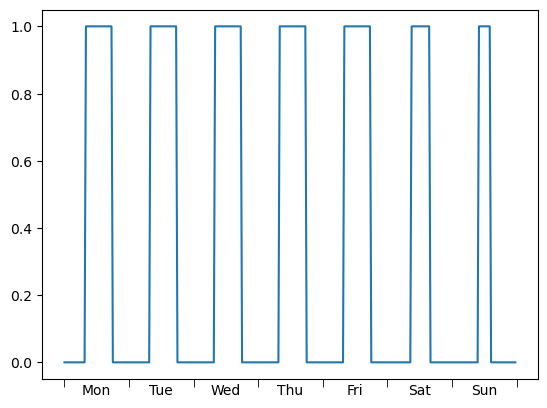

In [21]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

If, on the other hand, the user has set a daily demand profile to provide information on how the demanded power changes throughout the day, there is the possibility of specifying special daily demand profiles for the weekend by using the parameters `daily_demand_profile_saturday` and `daily_demad_profile_sunday`.

**In this case, an important feature to take into account is as follows:**

The philosophy of daily demand profiles is to make it simple for the user to introduce an approximate "shape" of the demand distribution in time throughout a 24-hour period. In order to keep this simplicity, the values introduced in different daily profiles are not assumed to have comparable scales. For this reason, it is ***necessary*** to also specify scalar values to set the scale of the demand on weekend days, such as the parameters `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday` explained above. See the following image and the explanation below for more clarification.  

<br>

<div style="text-align: center;">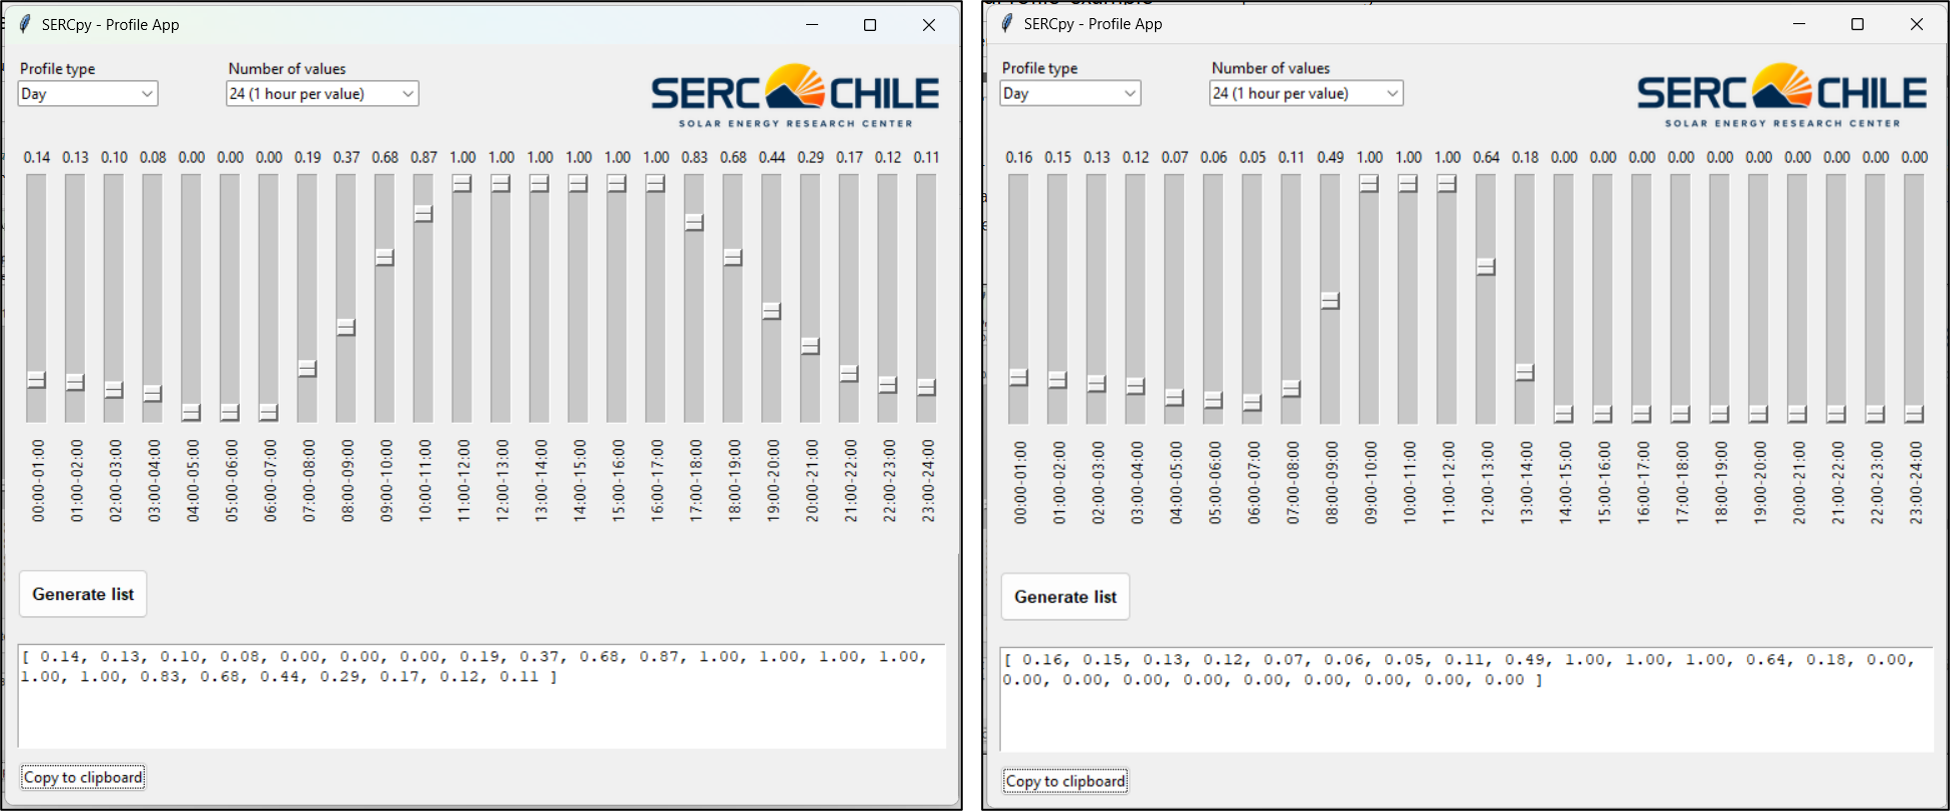</div>
<div style="text-align: center; font-weight: bold;">Demand profile for week days (left) and daily profile for saturdays (right)</div>

<br>

The image shows two different demand profiles. The one on the left is assumed to be a "normal" day (i.e., week day) and the one on the right is assumed to be the daily profile for saturday.

In this example, it is possible to infer that the thermal load only operates in the morning on saturdays. **However, the platform does not make any assumptions regarding how much energy the thermal load demands on saturdays (the peak demand could be the same as on week days, but this is not assumed by default)**.

Therefore, special daily profiles for weekend days must be specified along with scalar values defining the scale of the demand on those days.

In [22]:
# Specify the daily profile for saturday
daily_demand_profile_saturday = [
    0.16, 0.15, 0.13, 0.12, 0.07, 0.06,
    0.05, 0.11, 0.49, 1.00, 1.00, 1.00,
    0.64, 0.18, 0.00, 0.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00 ]

# Just for clarity, the parameter 'daily_demand_ratio_saturday' is defined again
daily_demand_ratio_saturday = 0.6

# Define the instance of 'DemandProfile' again

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_profile_saturday = daily_demand_profile_saturday,
    daily_demand_ratio_saturday = daily_demand_ratio_saturday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


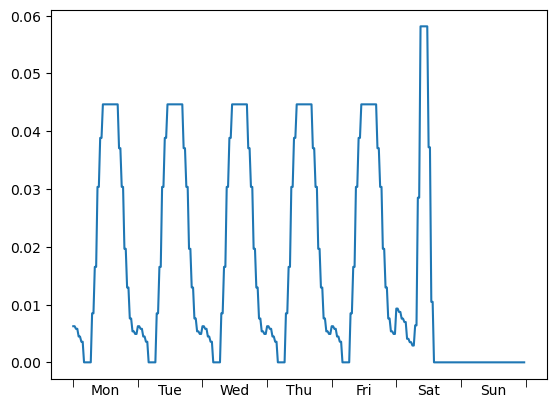

In [23]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### 3.3. Peak demand ratios

After plotting the weekly demand profile for the `DemandProfile` instance just created, the user may have found curious that the demand seems to be higher on saturdays despite having set the value of `daily_demand_ratio_saturday` at `0.6`.

This is because the argument `daily_demand_ratio_saturday` actually sets the ratio between the ***total*** daily demand on saturdays and the ***total*** daily demand on week days. Since the thermal load operates less time on saturdays, it has to reach a higher peak to achieve the demand ratio specified.

In order to set the peak demand for weekend days instead of the total daily demand, the user can specify the arguments `peak_demand_ratio_saturday` and `peak_demand_ratio_sunday`.

If no special profiles are provided for weekend days, then the arguments `peak_demand_ratio_saturday` and `peak_demand_ratio_sunday` have the same effect as `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday`.

In [24]:
# Set the peak demand for saturday instead of the total daily demand

peak_demand_ratio_saturday = 0.6

demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    daily_demand_profile_saturday = daily_demand_profile_saturday,
    peak_demand_ratio_saturday = peak_demand_ratio_saturday,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


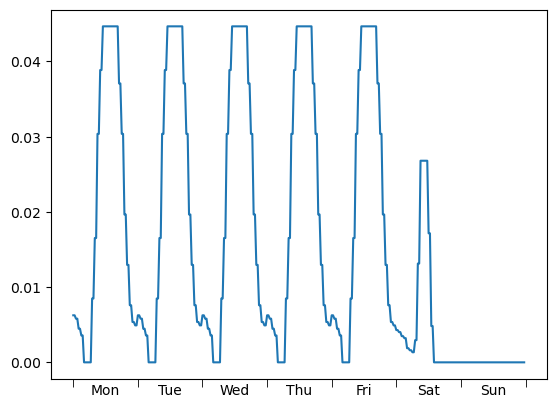

In [25]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

## 4. Costomizing the demand for all days of the week

### 4.1. Setting a different "daily demand ratio" for every day of the week

The parameters `daily_demand_ratio_saturday` and `daily_demand_ratio_sunday` previously discussed are meant to set the total daily demand for the weekend days comparing them with a "normal" week day.

In order to set a different "daily demand ratio" for every day of the week, there is the parameter `weekly_demand_factors`, which consists of a list of seven values. These values are interpreted as the ***relative total*** heat demand for each day of the week, starting on monday.

The App Profile can also be used to define this parameter, as the image shows.

<br>

<div style="text-align: center;">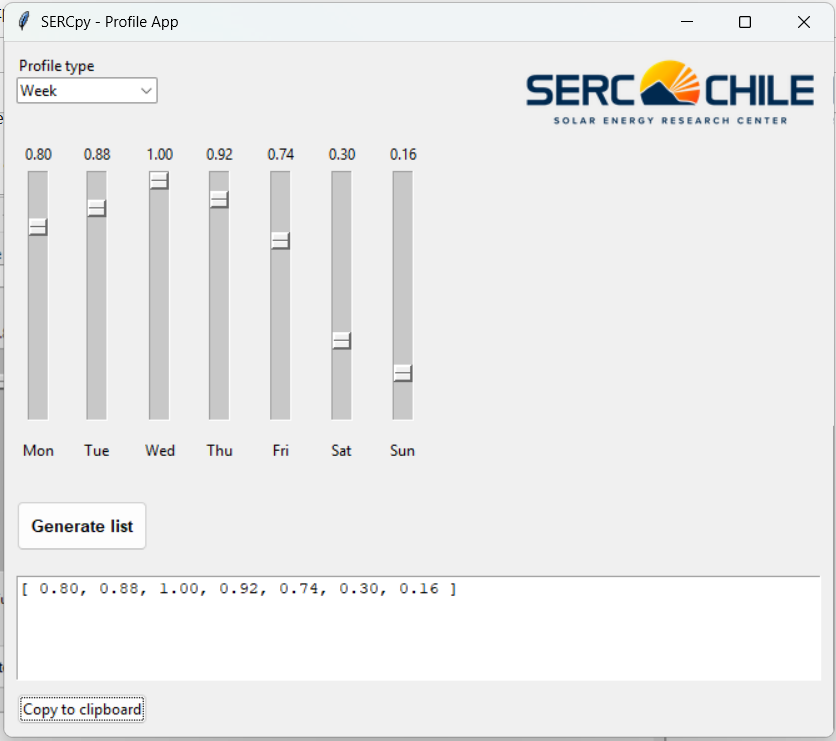</div>
<div style="text-align: center; font-weight: bold;">Profile App at the moment of creating the list of weekly demand factors</div>

<br>

As shown in the code cells below, this approach has been combined with a single daily demand profile that applies to all days of the week; by doing this, the profile has roughly the same shape every day but gets scaled by different factors.

In [26]:
# Open app to define profiles. The lists are printed in a text box and must be copied and pasted to the code.
DemandProfile.open_profiles_app()

In [27]:
# Define the parameter 'weekly_demand_factors'
weekly_demand_factors = [ 0.80, 0.88, 1.00, 0.92, 0.74, 0.30, 0.16 ]

In [28]:
# Using a single daily demand profile and scaling it every day by a different factor by using the argument 'weekly_demand_factors'

demand_1 = DemandProfile(
    
    daily_demand_profile = daily_demand_profile,
    weekly_demand_factors = weekly_demand_factors,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


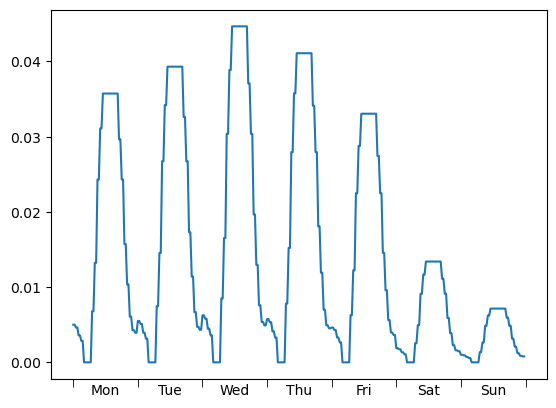

In [29]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### 4.2. Setting a different demand profile for every day

If the user needs to specify a different daily profile for each day of the week, there is the argument `daily_demand_profiles` (notice the difference with `daily_demand_profile`).

The argument `daily_demand_profiles` is a list of seven lists, where each list represents the profile of one day, starting on monday.

Following the assumption that profiles of different days are not comparable as being on the same scale, the argument `daily_demand_profiles` ***always*** has to be specified along with the parameter `weekly_demand_factors`.

In [30]:
# Define the parameter 'daily_demand_profiles'

daily_demand_profiles = [
    [ 14, 33, 67, 80, 89, 67, 60, 11 ],
    [ 49, 55, 67, 70, 74, 67, 60, 56 ],
    [ 23, 48, 58, 80, 52, 26, 17, 23 ],
    [ 70, 30, 33, 33, 38, 60, 70, 75 ],
    [ 0, 0, 67, 76, 77, 70, 0, 0 ],
    [ 19, 19, 67, 76, 77, 89, 38, 19 ],
    [ 19, 51, 67, 76, 77, 62, 38, 19 ],
]

demand_1 = DemandProfile(

    daily_demand_profiles = daily_demand_profiles,
    weekly_demand_factors = weekly_demand_factors,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


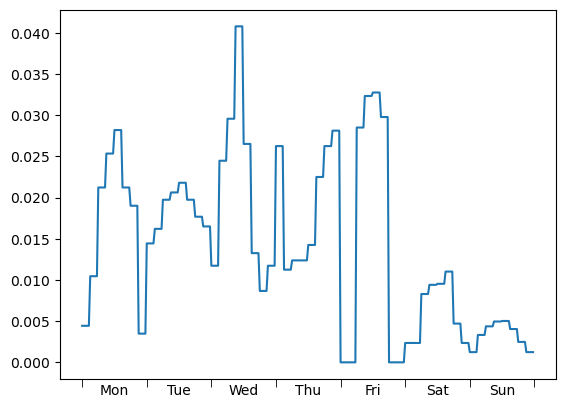

In [31]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

### 4.3. Specifying a single profile for the whole week

Until now, every time that more than one daily profile has been specified, the correct scale to compare the different profiles has been provided one way or another.

Nevertheless, there is also the option of specifying a profile that encompasses all days of the week without the platform worrying about how to compare them. This is done by joining all daily profiles in one long list and specifying it to the class `DemandProfile` under the name `weekly_demand_profile`.

**One important thing to care about is the following:**

The argument `daily_demand_profiles` is a list of lists representing the individual profile of each day. In this case, it is possible that each profile has a different number of values (less values imply that more hours of the day are encompassed by each value). However, this is not possible in the case of the argument `weekly_demand_profile`. In that case, all daily profiles must have the same length since they are being "concatenated" in one long list; therefore, the platform has no way to know where each day ends, other than dividing the total length of the weekly profile by 7.

In [32]:
# Define the parameter 'weekly_demand_profile'.
# This parameter has been constructed by converting the parameter 'daily_demand_profiles' defined earlier in one big list of values.

weekly_demand_profile = [
    14, 33, 67, 80, 89, 67, 60, 11,
    49, 55, 67, 70, 74, 67, 60, 56,
    23, 48, 58, 80, 52, 26, 17, 23,
    70, 30, 33, 33, 38, 60, 70, 75,
    0, 0, 67, 76, 77, 70, 0, 0,
    19, 19, 67, 76, 77, 89, 38, 19,
    19, 51, 67, 76, 77, 62, 38, 19,
]

demand_1 = DemandProfile(

    weekly_demand_profile = weekly_demand_profile,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

C:\Users\adria\OneDrive\Escritorio\PUC\Libreria_SHIPcal\lib\sercpy\demand_profile.py:1393: UserWarning: Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.
  warnings.warn("Class DemandProfile: Attribute 'Tamb_profile' has not been defined. The dependence of demand on ambient temperature will not be considered.")


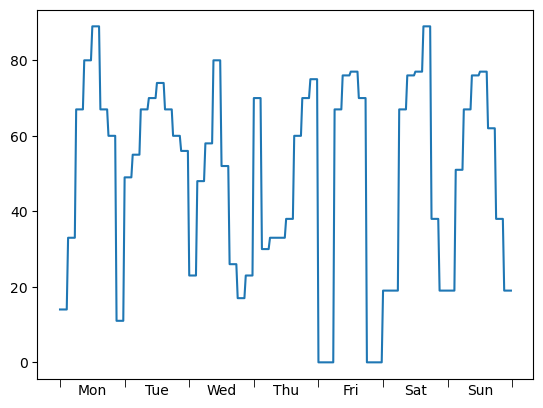

In [33]:
# Plot the weekly profile of the DemandProfile instance just created
plot_weekly_profile( demand_1 )

## 5. Dependence of thermal demand on ambient temperature

Depending on the type of thermal load, the energy demand could be heavily dependent on ambient temperature. An obvious example is room heating.

The paper presented by Jesper et al. [1] proposes four discrete levels of dependence. The following image shows how the same yearly demand gets distributed among the 12 months of the year with each dependence level. The temperature data used to predict the distributions corresponds to a typical meteorological year (TMY) file provided by the "Explorador Solar" of the Ministry of Energy of Chile [2]. The location used to generate the TMY file is the "San Joaquin" Campus of the Pontifical Catholic University of Chile. 

<br>

<div style="text-align: center;">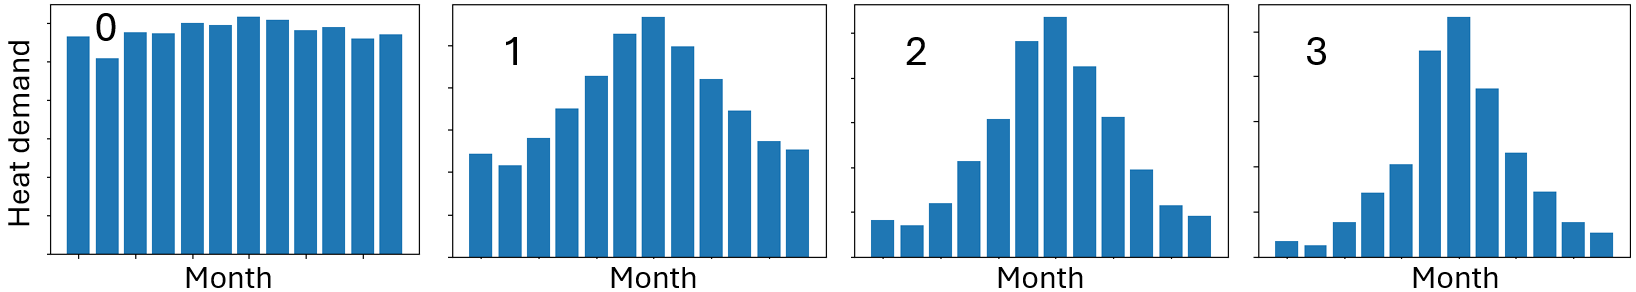</div>
<div style="text-align: center; font-weight: bold;">Monthly demand profiles assuming four different levels of dependence of the thermal demand on ambient temperature</div>

<br>

Sercpy has expanded the method proposed by Jesper et al. [1] to consider a continuous spectrum of dependence levels instead of the four discrete levels originally proposed. Moreover, the platform includes an algorithm to determine the dependence level based on the monthly heat demand provided by the user.

[1]   Mateo Jesper, Felix Pag, Klaus Vajen, Ulrike Jordan. Annual Industrial and Commercial Heat Load Profiles: Modeling Based on k-Means Clustering  and Regression Analysis. Energy Conversion and Management: X, Volume 10, June 2021, 100085

[2]   Explorador Solar, Ministry of Energy of Chile. URL: https://solar.minenergia.cl/inicio

### 5.1. Setting the ambient temperature profile

In order to determine the level of dependence of the thermal demand on the ambient temperature, an ambient temperature profile encompassing a whole year must be provided.  

This profile must have at least a daily resolution; i.e., 365 values, where each value represents the average temperature of each day. It is also allowed to provide profiles with higher resolution, but the number of elements in the profile must be a multiple of 365, and it always has to represent an entire year of data.  

Ideally, the data provided should correspond to the same year in which the thermal demand was registered. In this example, the same TMY data file mentioned above will be used.

In [34]:
# Import the TMY data file and convert the ambient temperature column to a list

tmy_data = pd.read_csv( "TMY_San_Joaquin.csv" )
Tamb_profile = tmy_data[ "temp" ].values.astype(float).tolist()

In [35]:
demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    weekly_demand_factors = weekly_demand_factors,
    monthly_heat_demand = monthly_heat_demand,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

### 5.2. Getting the level of dependence of thermal demand on ambient temperature

Since an ambient temperature profile was provided to the `DemandProfile` object when it was initialized, a level of temperature dependence was automatically determined. It is possible to get that value by using the method `demand_1.get_attribute()`. In this case, the name of the attribute is `"Tamb_dependence"`:

In [36]:
print( demand_1.get_attribute( "Tamb_dependence" ) )

0.878320312500001


### 5.3. Specifying the monthly production

The method just shown to determine the dependence of thermal demand on ambient temperature implicitly assumes that the only cause for having different demand levels throughout the year is changes in ambient temperature.

Nevertheless, it must me considered that different demand levels also could be casued by changes in production levels. To take this into account, the user can provide the optional parameter `monthly_production`, which also consists of a list of 12 values. The production units do not actually matter; what matters is how the numbers change from one month to another.

The production profile shown in the image below implies that some (although not all) of the variance in demand is due to changes in production levels; therefore, the dependence coefficient should be lower this time.

<br>

<div style="text-align: center;">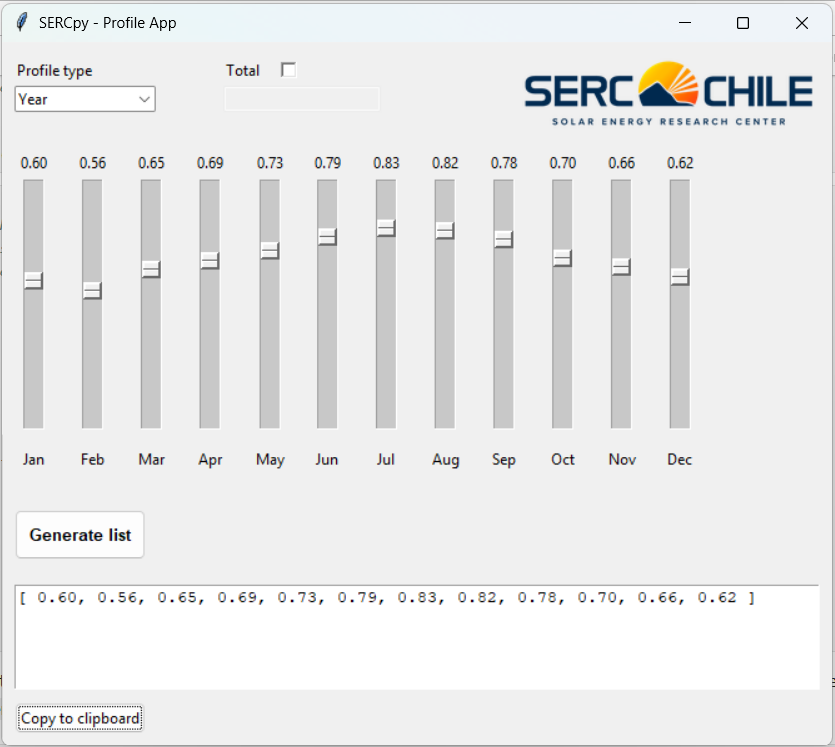</div>
<div style="text-align: center; font-weight: bold;">Profile App at the moment of establishing the monthly production</div>

In [37]:
# Introduce a monthly production profile
monthly_production = [ 0.60, 0.56, 0.65, 0.69, 0.73, 0.79, 0.83, 0.82, 0.78, 0.70, 0.66, 0.62 ]

# Define a new DemandProfile instance including the monthly production
demand_1 = DemandProfile(

    daily_demand_profile = daily_demand_profile,
    monthly_heat_demand = monthly_heat_demand,
    monthly_production = monthly_production,
    heat_demand_units = heat_demand_units,
    Tamb_profile = Tamb_profile,
    fluid = fluid,
    T_set = T_set,
    T_in = T_in,
    
)

In [38]:
# The dependence of demand on ambient temperature is indeed lower in this case
print( demand_1.get_attribute( "Tamb_dependence" ) )

0.5764648437500002


## 6. Obtaining data from DemandProfile instances

`DemandProfile` instances are meant to store the demand data for a whole operation year of the heating system. The data they store is:

- Flowrate
- Temperature of the flow entering the heating system
- Setpoint of the system
- Demanded power

The demand conditions can be obtained using the `DemandProfile.get_demand_conditions()` method.

### 6.1. Demand conditions for single instants in time

When the conditions for a single instant in time are asked for, the method `DemandProfile.get_demand_conditions()` returns a dictionary with the following components:

- `"flowrate"`
- `"demanded_power"`
- `"T_in"`
- `"T_set"`

The variables inside this dictionary are numeric values corresponding to that instant.

The instant provided as input should be either a `datetime.datetime` object, a `pandas.Timestamp` object, or a `dictionary` with the components `"month"`, `"day"`, `"hour"`, and `"minute"`. It is also possible to skip this positional argument and provide the components just mentioned as keyword arguments to the method `get_demand_conditions`.

In [39]:
# Setting the instant as a datetime.datetime object
instant_1 = datetime( year = 2026, month = 5, day = 14, hour = 15, minute = 47 )

# Asking for the conditions with the method get_demand_conditions()
print( demand_1.get_demand_conditions( instant_1 ) )

{'flowrate': 5.3783182741530755, 'demanded_power': 450057.6731811294, 'T_in': 40.0, 'T_set': 60.0}


By default, the units of the returned quantities are in the SI system, except for temperature which is returned in C. The flowrate is returned by default as mass flowrate (in kg/s).

The units can be customized with the keyword arguments `flowrate_units`, `power_units`, and `temp_units` (or equivalently, `T_units`).

The flowrate can be automatically switched to volumetric flowrate simply by specifying units that correspond to that type of flowrate.

In [40]:
# Setting custom units for the demand conditions 
power_units = "kW"
flowrate_units = "m3/h"
temp_units = "F"

# Asking for the conditions with the method get_demand_conditions()
print( demand_1.get_demand_conditions( instant_1, power_units = power_units, flowrate_units = flowrate_units, temp_units = temp_units )  )

{'flowrate': 19.361945786951072, 'demanded_power': 450.05767318112936, 'T_in': 104.0, 'T_set': 140.0}


Instead of defining a `datetime.datetime` instance or a `pandas.Tiemstamp` instance and providing it to the `get_demand_conditions` method, there are two alternative ways of obtaining the same behavior:

1. Passing the keyword arguments `month`, `day`, `hour`, and `minute` directly to the method.
2. Defining a dictionary which has the same keys as strings and passing it to the method instead of the `datetime.datetime`object.

In [41]:
# Obtaining the same results without passing the "instant_1" object to the method
# Keyword arguments are used instead

print( demand_1.get_demand_conditions( month = 5, day = 14, hour = 15, minute = 47 )  )

{'flowrate': 5.3783182741530755, 'demanded_power': 450057.6731811294, 'T_in': 40.0, 'T_set': 60.0}


In [42]:
# Obtaining the same results replacing the "instant_1" object with a dictionary

instant_1_dict = {
    "month": 5,
    "day": 14,
    "hour": 15,
    "minute": 47
}

print( demand_1.get_demand_conditions( instant_1_dict )  )

{'flowrate': 5.3783182741530755, 'demanded_power': 450057.6731811294, 'T_in': 40.0, 'T_set': 60.0}


### 6.2. Demand conditions throughout a period of time

When the demand conditions are generated for a period between two instants instead of a single instant, the object returned is not a dictionary anymore, but a `pandas.DataFrame`. The first column of the `pandas.DataFrame` returned is called `"timestamp"`, and it contains all the instants considered for the data generation. The other columns have the same names as the components of the dictionary that gets returned for single instants.

Getting the demand conditions for time periods can be done in two ways:

1. By passing two time instants as positional arguments to the method `get_demand_conditions`.  
2. By passing a single `pandas.Datetimeindex` object as positional argument to the method.  

The first method just mentioned internally generates a `pandas.Datetimeindex` from the two positional arguments specified. By default, the `pandas.Datetimeindex` is created with the following configuration:

- `freq="min"`
- `inclusive="both"`
- `tz=None`

This configuration can be modified by passing the aforementioned arguments as keyword arguments to the `get_demand_conditions` method.

In [43]:
# Defining a pandas.Datetimeindex instance
dt1 = datetime( year = 2025, month = 3, day = 14, hour = 15, minute = 25 )
dt2 = datetime( year = 2025, month = 6, day = 23, hour = 10, minute = 48 )
datetimes = pd.date_range( dt1, dt2, freq = "min", inclusive = "both" )

# Obtaining the data from the DemandProfile instance using the pandas.Datetimeindex instance
print( demand_1.get_demand_conditions( datetimes ) )

                 timestamp  flowrate  demanded_power  T_in  T_set
0      2025-03-14 15:25:00  3.534186   295740.694575  40.0   60.0
1      2025-03-14 15:26:00  3.534186   295740.694575  40.0   60.0
2      2025-03-14 15:27:00  3.534186   295740.694575  40.0   60.0
3      2025-03-14 15:28:00  3.534186   295740.694575  40.0   60.0
4      2025-03-14 15:29:00  3.534186   295740.694575  40.0   60.0
...                    ...       ...             ...   ...    ...
145159 2025-06-23 10:44:00  5.733359   479767.509805  40.0   60.0
145160 2025-06-23 10:45:00  5.733359   479767.509805  40.0   60.0
145161 2025-06-23 10:46:00  5.733359   479767.509805  40.0   60.0
145162 2025-06-23 10:47:00  5.733359   479767.509805  40.0   60.0
145163 2025-06-23 10:48:00  5.733359   479767.509805  40.0   60.0

[145164 rows x 5 columns]


In [44]:
# Getting the same behavior by providing the two timestamps as positional arguments to the method 'get_demand_conditions'

print( demand_1.get_demand_conditions( dt1, dt2 ) )

                 timestamp  flowrate  demanded_power  T_in  T_set
0      2025-03-14 15:25:00  3.534186   295740.694575  40.0   60.0
1      2025-03-14 15:26:00  3.534186   295740.694575  40.0   60.0
2      2025-03-14 15:27:00  3.534186   295740.694575  40.0   60.0
3      2025-03-14 15:28:00  3.534186   295740.694575  40.0   60.0
4      2025-03-14 15:29:00  3.534186   295740.694575  40.0   60.0
...                    ...       ...             ...   ...    ...
145159 2025-06-23 10:44:00  5.733359   479767.509805  40.0   60.0
145160 2025-06-23 10:45:00  5.733359   479767.509805  40.0   60.0
145161 2025-06-23 10:46:00  5.733359   479767.509805  40.0   60.0
145162 2025-06-23 10:47:00  5.733359   479767.509805  40.0   60.0
145163 2025-06-23 10:48:00  5.733359   479767.509805  40.0   60.0

[145164 rows x 5 columns]
